Jeśli używamy notebooka lokalnie należy zaistalowac qiskit 

* https://www.ibm.com/quantum/qiskit  
* https://quantum.cloud.ibm.com/docs/en/guides
* Opcjonalnie : google collab https://quantum.cloud.ibm.com/docs/en/guides/online-lab-environments#google-colab

Lokalna symulacja ``pip install qiskit``

Dla ładniejszej wizualizacji obwodów :
``pip install qiskit[visualization]``

Użycie urządzeń kwantowych IBM ``pip install qiskit-ibm-runtime``

Do symulacji urządzeń powyżej 24 qbitów oprócz ``qiskit-ibm-runtime`` potrzebny jest pakiet qiskit_aer   ``pip install qiskit-aer``

In [1]:
#!pip install qiskit

In [2]:
#!pip install qiskit-ibm-runtime

In [3]:
#!pip install qiskit[visualization]

In [4]:
#!pip install qiskit-aer

In [1]:
import warnings
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

Tworzymy prosty obwód kwantowy produkujący stan GHZ

In [2]:
qnumber=3
qc= QuantumCircuit(qnumber)
# Add a H gate on qubit 0, putting this qubit in superposition.
qc.h(0)
# Add a CX (CNOT) gate on control qubit 0 and target qubit 1, putting
# the qubits in a Bell state.
qc.cx(0,1)
# Add a CX (CNOT) gate on control qubit 0 and target qubit 2, putting
# the qubits in a GHZ state.
qc.cx(0,2)


display(qc.draw())

┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

### Dokładne podglądanie stanów za pomocą <b><a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/quantum_info"> Quantum info library</a> </b> 

lokalnie uruchamiany symulator Statevector

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector


In [3]:
#używamy dokładnego symulatora statevector lokalnie
state = Statevector.from_instruction(qc)

In [4]:
# stan wyświetlony symbolicznie (działa dla prostych przypadków
# Inne opcje: https://docs.quantum.ibm.com/api/qiskit/qiskit.quantum_info.Statevector#draw 
state.draw('latex')

<IPython.core.display.Latex object>

In [5]:
# można zobaczyć wyliczone amplitudy (numeryczne wartości w postaci zespolonej)
print(state)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))


In [6]:
for x in range(pow(2,qnumber)):
    print(x,state[x])

0 (0.7071067811865475+0j)
1 0j
2 0j
3 0j
4 0j
5 0j
6 0j
7 (0.7071067811865475+0j)


In [7]:
from qiskit.visualization import array_to_latex

#alternatywny sposób
array_to_latex(state)

<IPython.core.display.Latex object>

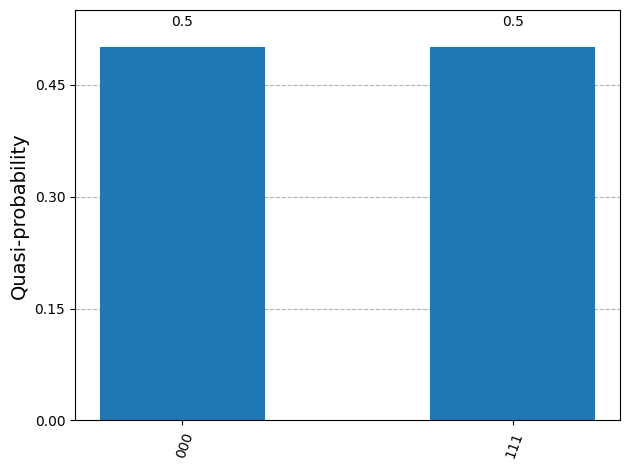

In [8]:
# można też narysować histogram z wyliczonymi prawdopodobieństwami (wynik idealny) 
ideal_distribution = state.probabilities_dict()

plot_histogram(ideal_distribution)

Powyższe sposoby można stosować do mniejszych obwodów, aby podglądnąć dokładny stan (proszę zauważyć, że powyżej nie dodaliśmy bramek pomiaru !). 

W prawdziwym urządzeniu takie obliczenie nie jest to możliwe. Musimy dokonać pomiaru. 
Symulacja pomiaru za pomocą Statevectora  

In [9]:
outcome, measured_state = state.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(measured_state.draw("latex"))

Measured: 111
Post-measurement state:


<IPython.core.display.Latex object>

Aby zasumulować rzeczywiste uruchomienie obwodu na urządzeniu kwantowym używamy metody  symulującej  podaną liczbę (tutaj 1000) pomiarów w systemie, każdorazowo rozpoczynając od świeżej kopii stanu. Słupki histogramu nie są już dokładnie wyliczane tylko losowane.

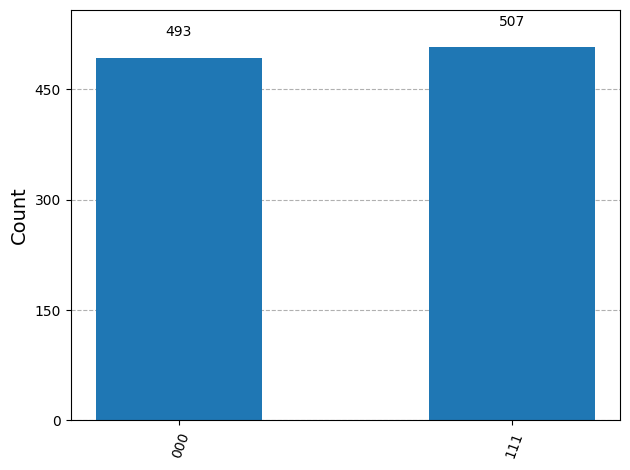

In [10]:
statistics = state.sample_counts(1000)
plot_histogram(statistics)

### Symulacja uruchomienia z API jak na prawdziwym urządzeniu za pomocą <a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/primitives">Qiskit primitives</a>
W aktualnej wersji qiskita  wprowadzono dwa podstawowe sposoby (https://docs.quantum.ibm.com/api/qiskit/primitives) do uzyskiwania danych w sposób zgodny z mechaniką kwantową z uruchomienie obwodu kwantowego : 
 - *Estimator*  - szacujący wartość oczekiwaną pewnej obserwabli (wykracza poza ten kurs) 
 - *Sampler* - losujący wyniki zgodnie z zasadami pomiaru kwantowego.

Poniższy przykład pokazuje użycie prymitywu *Sampler* lokalnie

In [11]:
display(qc.draw())

┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

### WAZNE: musimy dodać bramki pomiaru do obwodu  !!

In [12]:
qc.measure_all()
display(qc.draw())

┌───┐           ░ ┌─┐      
   q_0: ┤ H ├──■────■───░─┤M├──────
        └───┘┌─┴─┐  │   ░ └╥┘┌─┐   
   q_1: ─────┤ X ├──┼───░──╫─┤M├───
             └───┘┌─┴─┐ ░  ║ └╥┘┌─┐
   q_2: ──────────┤ X ├─░──╫──╫─┤M├
                  └───┘ ░  ║  ║ └╥┘
meas: 3/═══════════════════╩══╩══╩═
                           0  1  2

In [13]:
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes

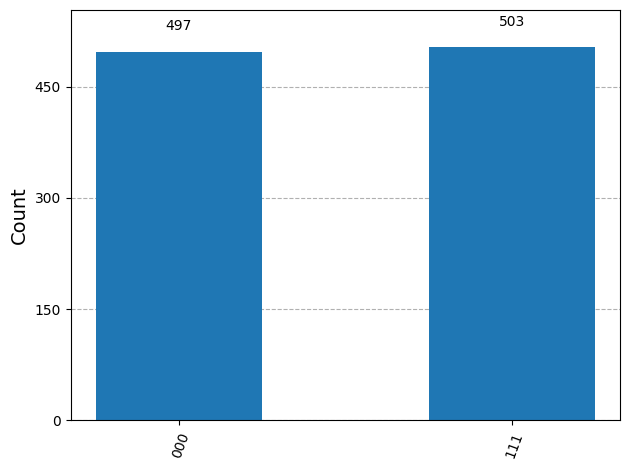

In [14]:
# inicjalizujemy Sampler
sampler = Sampler()
 
# symulujemy  obwód od nowa 1000 razy za każdym razem odpowiednio losując wynik (losowanie klasyczne na lokalnym komputerze)
# działanie podobne state.sample_counts() za pomocą StateVectora z biblioteki qiskit.quantum_info , 
# ale API przygotowuwujące do uruchomienia na prawdziwym urządzeniu
job = sampler.run([qc], shots=1000)
job_result = job.result()

pub_result = job.result()[0]
counts = pub_result.data.meas.get_counts()
#wyniki na histogramie 
plot_histogram(counts)

### Uruchomienie na infrastrukturze IBM
Uwaga: niestety mogą być przestoje
W celu podłączenia się do infrastruktury IBM należy:
* założyć konto na https://quantum.cloud.ibm.com/
* postawić instancję (klasycznej) maszyny wirtualnej na IBM Cloud region Washington DC (us-east)
* UWAGA: zasoby będą dostępne tylko 28 dni (10 minut na prawdziwym urządzeniu)
* ustawić token API https://cloud.ibm.com/iam/apikeys
  
Szczegółowe instrukcje https://quantum.cloud.ibm.com/docs/en/guides/cloud-setup

### UWAGA uważać z tokenem przy współdzieleniu noteboków !
Najprościej zapisać token na dysku

In [19]:
#from qiskit_ibm_runtime import QiskitRuntimeService
 
#QiskitRuntimeService.save_account(
#  token="<your token>", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
#  set_as_default=True, # Optional
#  overwrite=True, # Optional
#)

In [15]:
#jeśli zapisaliśmy token na dysku, wystarczy go wczytać
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2026-01-26 16:26:06,802: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [21]:
#alternatywa, jeśli nie mamy zapisanego tokenu na dysku i chcemy go podać wprost (ale trzeba uważać przy współdzielenie notebooków)
#from qiskit_ibm_runtime import QiskitRuntimeService
#service = QiskitRuntimeService(token="<your token")

In [16]:
#wybieramy najmniej zajęte urządzenie kwantowe.
backend = service.least_busy(simulator=False, operational=True)
print("wybrane urządzenie to ", backend)

qiskit_runtime_service.backends:WARNING:2026-01-26 16:26:10,283: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-01-26 16:26:12,128: Using instance: open-instance, plan: open


wybrane urządzenie to  <IBMBackend('ibm_torino')>


### Transpilacja 
transpilacja = przetłumaczenie obwodu na bramki wspierane przez urządzenie.

Przykładowo dla ibm_torino można to sprawdzić tutaj https://quantum.ibm.com/services/resources?system=ibm_torino

Możliwe jest ustawienie poziomu optymalizacji od 0 do 3

brak optymalizacji powoduje wystąpienie 5 ciu bramek kontrolnych (nie ma połączenia pomiędzy qbitami 0 i 2)

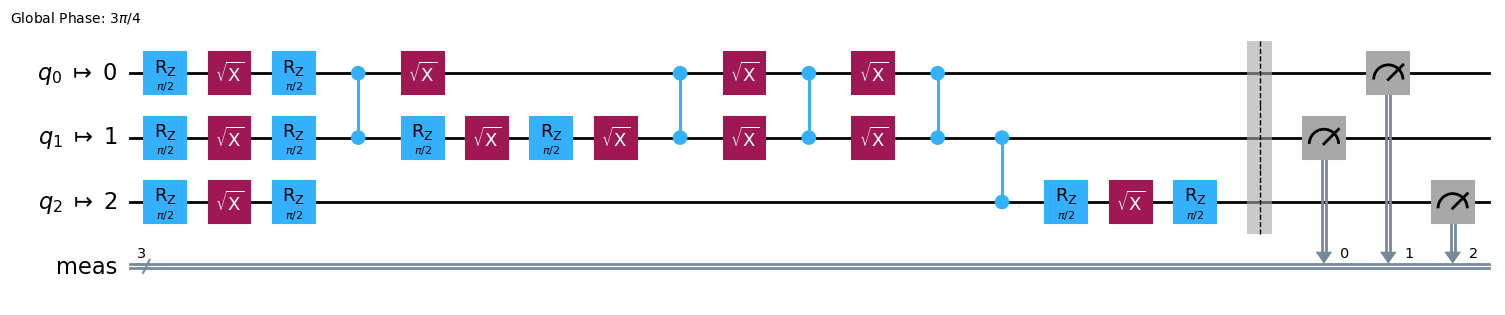

In [17]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
isa_circuit = pm.run(qc)
 
isa_circuit.draw("mpl", idle_wires=False)

Tutaj w procesie optymalizacji wykorzystano bezpośrednie połączenie w architekturze pomiędzy qbitem 37 i 52 oraz 51 i 52 

https://quantum.cloud.ibm.com/computers?system=ibm_torino

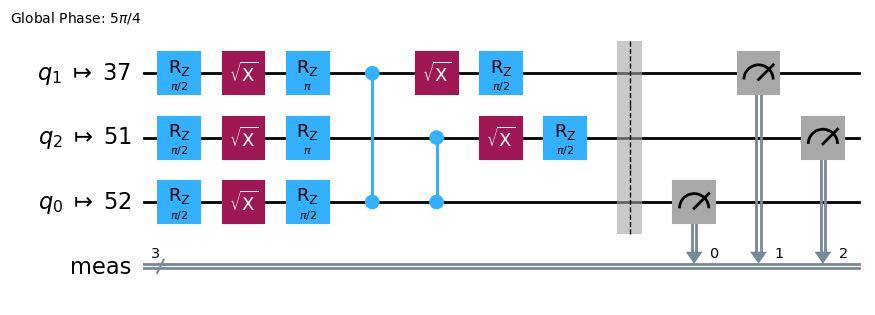

In [18]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(qc)
 
isa_circuit.draw("mpl", idle_wires=False)

In [19]:
from qiskit_ibm_runtime import SamplerV2 as IBMSampler

In [20]:
sampler = IBMSampler(mode=backend)

In [21]:
job = sampler.run([(isa_circuit)])
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: d5rof9rt11qc73e0umkg
>>> Job Status: QUEUED


In [23]:
print(f">>> Job Status: {job.status()}")

>>> Job Status: DONE


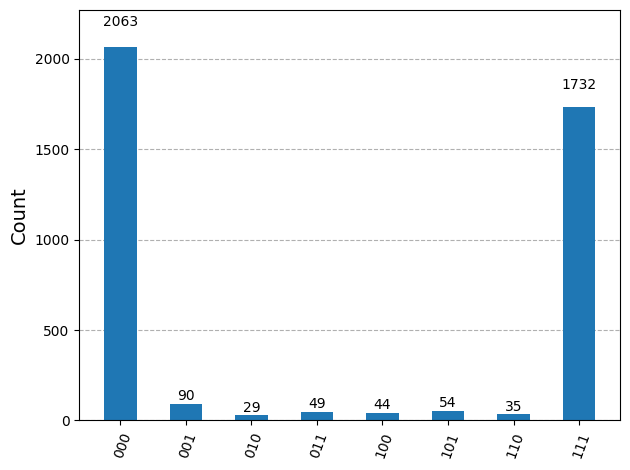

In [24]:
#Wyniki: Uwaga: pojawiły się stany, które nigdy nie powinny wyjść z teoretycznych wyliczeń !
result = job.result()
pub_result = result[0]
ibmcounts = pub_result.data.meas.get_counts()
#wyniki na histogramie 
plot_histogram(ibmcounts)

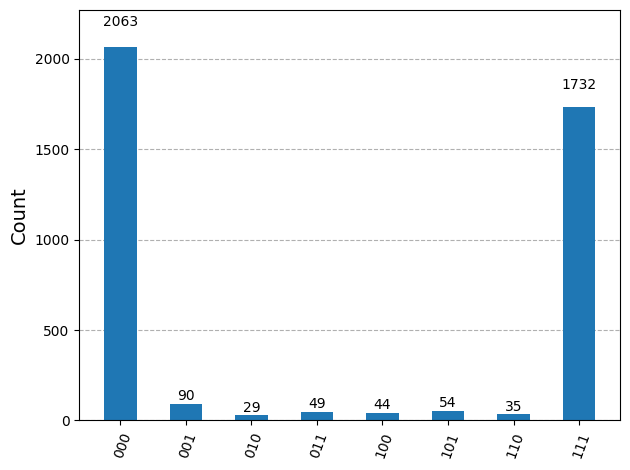

In [26]:
# można będzie potem  wyciągnąć wyniki ze starego joba po jego numerze wziętym z https://quantum.ibm.com/workloads

result_dev = service.job('d5rof9rt11qc73e0umkg').result()
ibmcounts = result_dev[0].data.meas.get_counts()

plot_histogram(result_dev[0].data.meas.get_counts())


### Jeśli dostęp do urządzeń kwantowych się skończy/kolejka byłaby za długa - jest też dostępny LOKALNY symulator prawdziwych urządzeń (z ich modelem błędów) 
https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/fake-provider

UWAGA: do symulacji więcej niż 24 qbitowegop urządzenia potrzebny jest ``qiskit-aer``

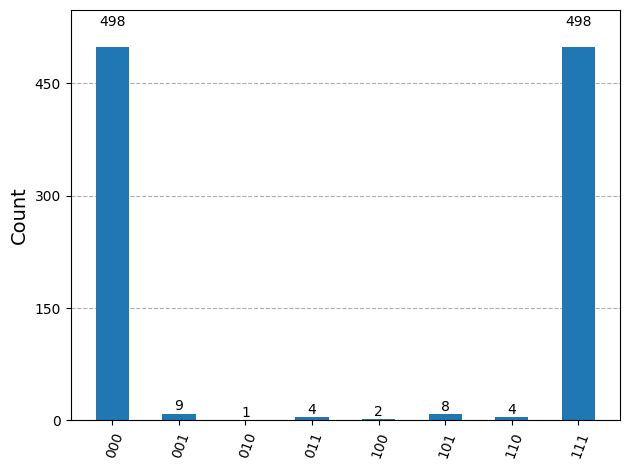

In [28]:
# To samo API, z backendem będącym symulatorem konkretnego urządzenia kwantowego
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeTorino
from qiskit_ibm_runtime import SamplerV2 as IBMSampler
from qiskit_aer import AerSimulator

backend= FakeTorino()
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
sampler = IBMSampler(mode=backend)
job = sampler.run([(isa_circuit)])
result = job.result()
pub_result = result[0]
fakeibmcounts = pub_result.data.meas.get_counts()
#wyniki na histogramie 
plot_histogram(fakeibmcounts)

Przegląd lokalnych symulatorów dostępnych w qiskit https://quantum.cloud.ibm.com/docs/en/guides/local-simulators

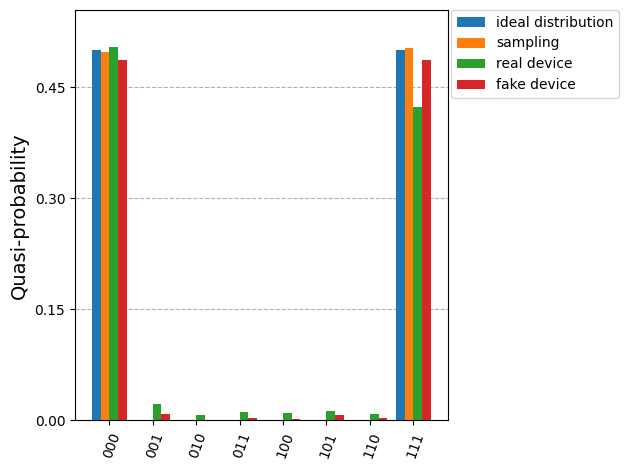

In [29]:
# porównanie histogramów 
binary_prob = [ideal_distribution, counts,ibmcounts, fakeibmcounts]
plot_histogram(
    binary_prob,
    bar_labels=False,
    legend=[
        "ideal distribution",
        "sampling",
        "real device",
        "fake device"
    ],
)

In [30]:
import qiskit
qiskit.version.get_version_info()

'2.3.0'

In [31]:
import qiskit_ibm_runtime
qiskit_ibm_runtime.version.get_version_info()

'0.45.0'